In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.info() # Bu kod bize sütun adlarını, veri tiplerini ve eksik değer olup olmadığını gösterir.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
df.shape # satır ve sütun sayısı

(768, 9)

In [29]:
df.describe() # istatistiksel özet

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [30]:
df.isnull().sum() # eksik veri kontrolü

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [31]:
df["Outcome"].value_counts(normalize=True) * 100 # Diabetes olan ve olmayanların sayısı(0 diabet olmayan, 1 diabet olan)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

"""
### **1. Glucose**
(Glikoz Kandaki şeker konsantrasyonunu ifade eder. Genellikle 2 saatlik oral glikoz tolerans testi sonucunu temsil eder. Diyabet teşhisinde en kritik sütun budur; çünkü şeker hastalığı, vücudun kandaki şekeri (glikozu) hücrelere taşıyamaması durumudur.
### **2. BloodPressure(Kan Basıncı)**
Buradaki değer diyastolik kan basıncıdır (halk arasında "küçük tansiyon"). Kalbin atışları arasında dinlendiği andaki damar baskısını ölçer. Diyabet, uzun vadede damar yapısını bozarak tansiyon sorunlarına yol açabildiği için önemli bir değişkendir.
### **3. SkinThickness (Cilt Kalınlığı)**
Genellikle triceps (arka kol) bölgesindeki deri kıvrım kalınlığıdır. Bu değer, vücuttaki deri altı yağ miktarını tahmin etmek için kullanılır. İnsülin direnci ve yağ dokusu arasındaki ilişkiyi analiz etmeye yardımcı olur.
### **4. Insulin(İnsülin)**
2 saatlik serum insülin miktarını belirtir. İnsülin, kandaki şekerin hücrelere girmesini sağlayan anahtardır. Diyabet hastalarında vücut ya yeterli insülin üretemez ya da var olan insülini kullanamaz (insülin direnci).
### **5. BMI(Vücut Kitle İndeksi)**
İngilizce Body Mass Index teriminin kısaltmasıdır. Kişinin kilosunun, boyunun karesine bölünmesiyle hesaplanır ($BMI = kg/m^2$). Obezite, Tip 2 diyabet için en büyük risk faktörlerinden biri olduğu için modellemede hayati bir rol oynar."""

### **Dikkat:**
Yaşayan bir insanın kan basıncı, glikoz değeri, cilt kalınlığı, insülin değeri veya vücut kitle endeksi değeri 0 olamaz. Bu durum, verinin aslında "eksik" (NaN) olduğunu ama sisteme 0 olarak kaydedildiğini gösteriyor. Modelimi eğitmeden önce bu 0 değerlerini ortalama (mean) veya medyan (median) ile dolduracağım ve sonuçlarının doğruluğunu arttıracağımı düşünüyorum.

In [32]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, "sıfır değer sayısı:", (df[col] == 0).sum())

Glucose sıfır değer sayısı: 5
BloodPressure sıfır değer sayısı: 35
SkinThickness sıfır değer sayısı: 227
Insulin sıfır değer sayısı: 374
BMI sıfır değer sayısı: 11


In [33]:
""" Burada 0 değerleri doğrudan silmek yerine NaN yapıp medyan ile dolduracağım. Çünkü veri seti zaten küçük, satır silersem veri kaybederim bu yüzden model doğruluğu düşer. """

df_clean = df.copy()

zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [34]:
# Medyan ile doldurma
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# **GÖRSELLEŞTİRME İŞLEMLERİ**

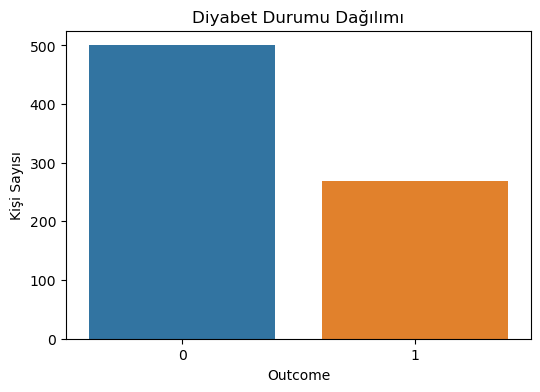

In [35]:
# Önce hedef değişken dağılımını görselleştirelim
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Outcome")
plt.title("Diyabet Durumu Dağılımı")
plt.xlabel("Outcome")
plt.ylabel("Kişi Sayısı")
plt.show()

# **Korelasyon Katsayısı ($r$) Nedir?**
Matristeki her bir hücre $-1$ ile $+1$ arasında bir değer alır:+1'e Yakın Değerler (Pozitif Korelasyon): Bir değişken artarken diğeri de artar. (Örneğin: BMI arttıkça diyabet riski genelde artar). -1'e Yakın Değerler (Negatif Korelasyon): Bir değişken artarken diğeri azalır. 0'a Yakın Değerler: Değişkenler arasında anlamlı bir doğrusal ilişki yoktur.

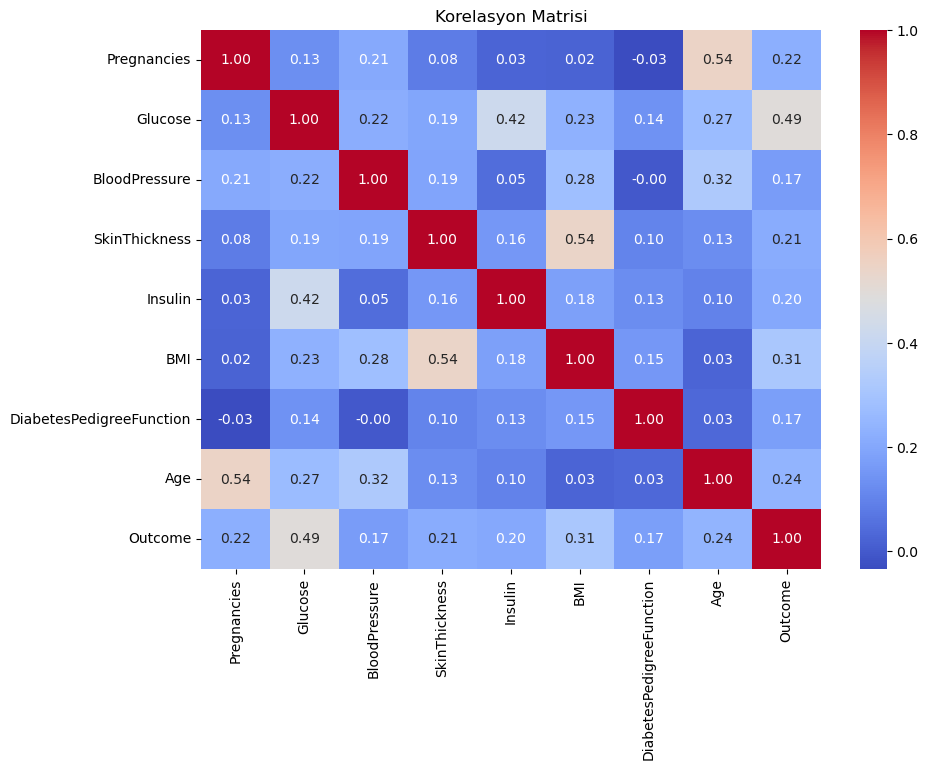

In [36]:
# korelasyon matrisi
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

# **Glikoz değerleri ve Diyabetle İlişkisi Analizi**


Diyabet olmayanların (0) dağılımı solda (düşük şekerlerde) yoğunlaşırken,

Diyabet olanların (1) dağılımı daha çok sağa(yüksek şekerlere) kaymış olacak. (Grilikler ve açık turuncu renkler diyabet olan hastaları gösteriyor)

c:\Users\Furkan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


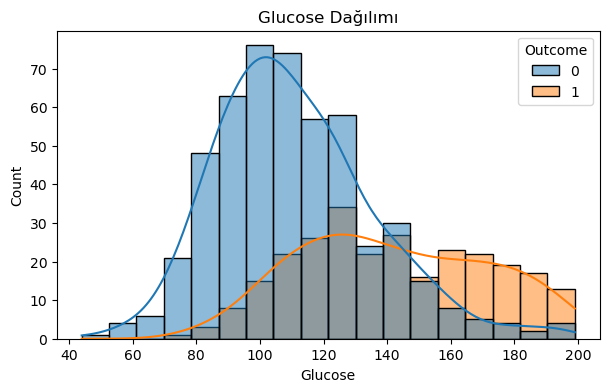

In [37]:

plt.figure(figsize=(7, 4))
sns.histplot(data=df_clean, x="Glucose", hue="Outcome", kde=True)
plt.title("Glucose Dağılımı")
plt.show()

# **BMI Dağılımı ve Diyabet İlişkisi Analizi**

## **1. Grafikteki Renkler Bize Ne Anlatıyor?**
Veriyi daha iyi anlayabilmek için diyabet durumuna göre iki gruba ayırdım:

**Mor Alan (Sağlıklı Grup):** Diyabet teşhisi konulmamış (Outcome=0) kişileri temsil ediyor. Fark ettiyseniz, bu grubun yoğunluğu grafiğin sol tarafında, yani düşük BMI değerlerinde toplanmış durumda.
**Turuncu/Pembe Alan (Diyabetli Grup):** Diyabet teşhisi konulmuş (Outcome=1) kişileri gösteriyor. Bu grubun dağılımı, sağlıklı gruba kıyasla bariz bir şekilde sağa (yüksek BMI değerlerine) doğru kaymış. Bu da bize kilonun diyabet üzerindeki etkisini ilk bakışta hissettiriyor.

---

## **2. Kritik Çizgiler ve Eşik Değerlerim**
Analizimi daha profesyonel kılmak için grafiğe iki önemli referans çizgisi ekledim:

**Yeşil Çizgi (Obezite Sınırı - 30):** Tıbbi olarak "obez" kabul edilen sınırı buraya işaretledim. Bu yeşil çizginin sağ tarafına geçtikçe turuncu sütunların (diyabetlilerin) ne kadar baskın hale geldiği netçe görülüyor.
**Kırmızı Kesikli Çizgi (Ortalamam - 32.5):** Veri setimdeki tüm kişilerin BMI ortalaması 32.5 çıktı. Bu değerin zaten obezite sınırının üzerinde olması, incelediğim grubun genel olarak riskli bir kilo aralığında olduğunu kanıtlıyor.

---

## **3. Bu Tablodan Çıkardığım Önemli Notlar**
Yaptığım bu görselleştirme sonucunda şu çıkarımlara ulaştım:

BMI değeri 30’un üzerine çıktığı andan itibaren, mor grafiğin (sağlıklıların) boyu kısalırken turuncu grafiğin (riskli grubun) yükseldiğini görüyorum. Bu da "Kilo arttıkça diyabet riski artar" tezimi doğrular nitelikte.

c:\Users\Furkan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


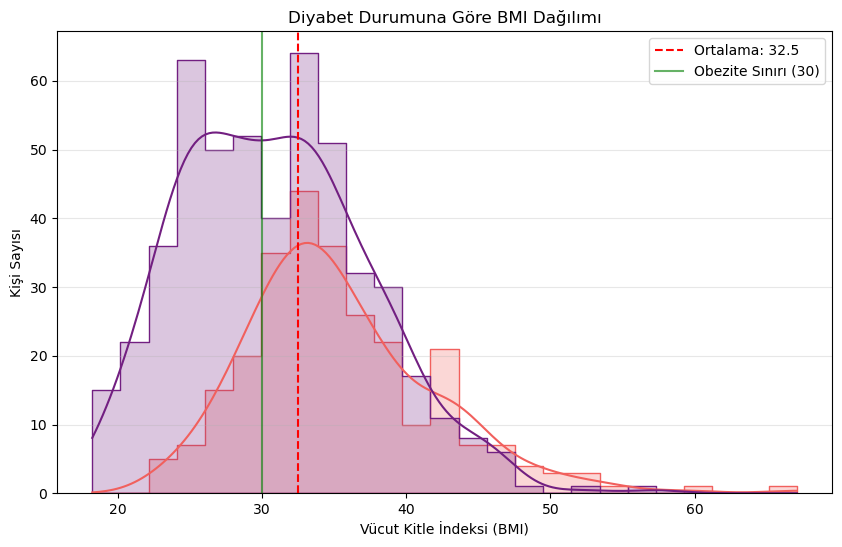

In [38]:
plt.figure(figsize=(10, 6))

# hue="Outcome" ile veriyi ikiye böldüm ve her iki grup için ayrı renkler kullandım
sns.histplot(data=df_clean, x="BMI", hue="Outcome", kde=True, palette="magma", element="step")

# Ortalama BMI değerini gösteren dikey bir çizgi ekledim
plt.axvline(df_clean["BMI"].mean(), color='red', linestyle='--', label=f'Ortalama: {df_clean["BMI"].mean():.1f}')

# Tıbbi obezite sınırı olan 30 değerine bir çizgi ekledim
plt.axvline(30, color='green', linestyle='-', alpha=0.6, label='Obezite Sınırı (30)')

plt.title("Diyabet Durumuna Göre BMI Dağılımı")
plt.xlabel("Vücut Kitle İndeksi (BMI)")
plt.ylabel("Kişi Sayısı")
plt.legend() # Çizgilerin ne olduğunu gösteren kutucuk
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Kan Basıncı ve Yaşın Diyabetle İlişkisi: İkili Görselleştirme Analizi**

Geliştireceğim makine öğrenmesi modeli öncesinde, veriyi daha geniş bir açıyla görebilmek adına tek bir tuval üzerinde iki farklı görselleştirme tekniğini birleştirdim. Sol tarafta genel tansiyon dağılımını, sağ tarafta ise yaş faktörüyle birleştiğindeki yığılmaları inceliyorum.

---

## **1. Sol Grafik: Kutu Grafiği (Boxplot) Bize Ne Söylüyor?**
Sol taraftaki kutu grafiği, tansiyon (BloodPressure) değerlerinin sağlıklı ve diyabetli gruplardaki dağılımını özetliyor:

* **Medyan (Ortanca) Farkı:** Yeşil kutu (sağlıklı grup) ile turuncu kutuyu (diyabetli grup) kıyasladığımda, turuncu kutunun içindeki yatay çizginin (medyanın) biraz daha yukarıda olduğunu fark ettim. Bu da beklendiği gibi, diyabetli bireylerde genel kan basıncı eğiliminin hafifçe daha yüksek olduğunu gösteriyor.
* **Aykırı Değerler (Outliers):** Grafiğin hem alt hem de üst kısımlarındaki o tekil elmas şeklindeki noktalar, veri setimde ekstrem tansiyon değerlerine sahip hastalar olduğunu kanıtlıyor. Özellikle 40'ın altındaki ve 100'ün üzerindeki bu değerleri, modelimi eğitirken nasıl ele alacağıma (tutmak veya baskılamak) karar vermem gerekecek.

---

## **2. Sağ Grafik: Yoğunluk Haritası (KDE) Bana Ne Anlatıyor?**
Sağ taraftaki grafikte nokta karmaşasından (overplotting) kurtulup, insanların yaş ve tansiyona göre yoğunlaştığı "zirveleri" haritalandırdım (Kırmızı=Sağlıklı, Mavi=Diyabetli):

* **Sağlıklı Grubun (Kırmızı) Zirvesi:** Sağlıklı bireylerin oluşturduğu kırmızı bulutun merkezi, grafiğin sol alt köşesinde (20-30 yaş arası ve 60-80 tansiyon bandında) çok net bir şekilde toplanmış durumda. Yani genç ve normal tansiyonlu kişiler ağırlıklı olarak sağlıklı grupta.
* **Diyabetli Grubun (Mavi) Kayması:** Mavi alanın merkezinin (en koyu mavi halkaların) kırmızıya göre bariz bir şekilde **sağa (daha ileri yaşlara)** ve hafifçe **yukarıya (daha yüksek tansiyona)** kaydığını gözlemliyorum. Mavi bulutun 40-60 yaş aralığında yayılması, yaş faktörünün diyabet üzerindeki baskın etkisini bir kez daha kanıtlıyor.

---

## **3. Bu Tablodan Çıkardığım Önemli Notlar**
* **Çakışma Bölgeleri:** İki bulutun üst üste bindiği (kırmızı ve mavinin karıştığı) geniş bir orta alan var. Bu şu anlama geliyor: Sadece yaşa ve tansiyona bakarak birinin kesin diyabetli olup olmadığını söyleyemeyiz. Modelimin yüksek doğruluk için mutlaka Glikoz ve BMI gibi diğer güçlü sütunlara da ihtiyacı olacak.
* **Tansiyonun Gücü:** Tansiyon tek başına diyabeti ayırt etmede "Age", "BMI" veya "Glucose" kadar keskin bir bıçak değil; ancak yaşla birlikte değerlendirildiğinde modeli destekleyecek güzel bir yan faktör (feature) görevi görecek.

c:\Users\Furkan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Furkan\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


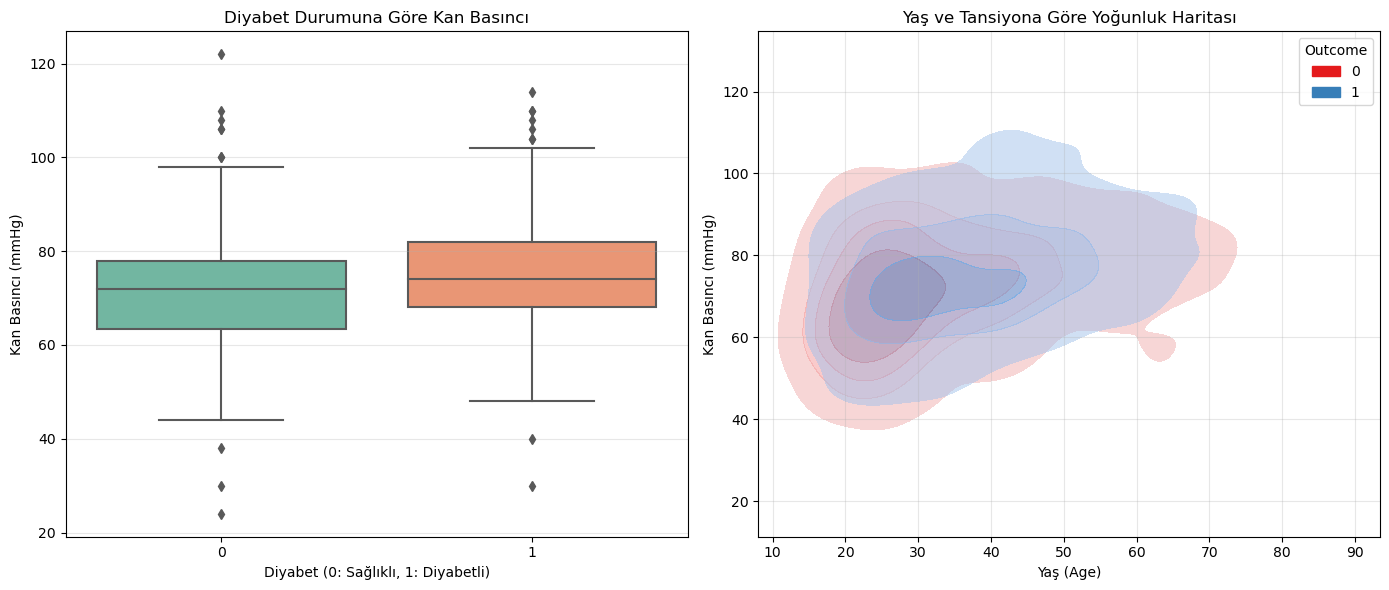

In [39]:
# 1 satır ve 2 sütundan oluşan, 14x6 boyutlarında geniş bir tuval açtım
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 1. GRAFİK (SOL TARAFA: Kutu Grafiği) ---
# ax=axes[0] parametresi ile sol tarafa atıyoruz
sns.boxplot(data=df_clean, x="Outcome", y="BloodPressure", palette="Set2", ax=axes[0])
axes[0].set_title("Diyabet Durumuna Göre Kan Basıncı")
axes[0].set_xlabel("Diyabet (0: Sağlıklı, 1: Diyabetli)")
axes[0].set_ylabel("Kan Basıncı (mmHg)")
axes[0].grid(axis='y', alpha=0.3)

# --- 2. GRAFİK (SAĞ TARAFA: KDE Yoğunluk Haritası) ---
# ax=axes[1] parametresi ile sağ tarafa atıyorum
sns.kdeplot(
    data=df_clean, 
    x="Age", 
    y="BloodPressure", 
    hue="Outcome", 
    fill=True,          
    alpha=0.5,          
    palette="Set1",
    levels=5,
    ax=axes[1]          # GRAFİĞİ SAĞA ATAN KOD BURASI
)
axes[1].set_title("Yaş ve Tansiyona Göre Yoğunluk Haritası")
axes[1].set_xlabel("Yaş (Age)")
axes[1].set_ylabel("Kan Basıncı (mmHg)")
axes[1].grid(True, alpha=0.3)

# Grafikler birbirine girmesin diye otomatik boşluk ayarı yaptım
plt.tight_layout()
plt.show()